# **Experiment Notebook**



In [1]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

<hr>

## A. Project


In [2]:
Type = 'Regression'

In [3]:
group_id = '26'

In [4]:
student_name = 'Max Chew '

In [5]:
student_id = '13552169'

<hr>

## B. Business Understanding


In [6]:
business_use_case = 'A regression model predicting monthly customer spend allows banks to enhance operational efficiency, offer targeted financial products, and target marketing strategies. It also may prove useful in fraud detection by identifying unusual spending patterns, protecting both the bank and its customers. It also has the ability to assist customers in managing their finances more effectively potentially resulting in higher satisfaction and loyalty and reducing churn.'

In [2]:
business_expectations = 'The goal is to create a regression model that accurately predicts future customer spend over a month period. Limitations have been placed on the data so that only information available before the target month can be used in making predictions in order to simulate unseen data and improve efficacy. We believe that with the available data we are able to provide valuable insight into the purchasing behaviour of customers and by building an accurate regression model. '

<hr>

## C. Data Understanding


### C.0 Import Packages

In [3]:
# Pandas for data handling
import pandas as pd

# Scikit Learn for ML training
import sklearn

# Altair for plotting
import altair as alt

# import matplot lib for plotting
import matplotlib.pyplot as plt

# nunmpy for math
import numpy as np

# import seaborn for plotting 
import seaborn as sns

<hr>

### C.1   Load Datasets

In [4]:
# Import dataset 

data = pd.read_csv('AT3_final_common_dataset.csv',sep=None)

/tmp/ipykernel_118/2701685668.py:3: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support sep=None with delim_whitespace=False; you can avoid this warning by specifying engine='python'.
  data = pd.read_csv('AT3_final_common_dataset.csv',sep=None)


In [3]:
# Check head 

data.head()


,cc_num,acct_num,trans_num,unix_time,category,amt,is_fraud,merchant,merch_lat,merch_long,...,gender,street,city,state,zip,lat,long,city_pop,job,dob
0,4891077119918081211,402211201664,3e83e0a77771558c6daf6bdd272f6c4c,1650832775,grocery_pos,57.81,0,Johnson and Sons,38.537479,-82.777755,...,F,478 Oconnor Courts,New Plymouth,OH,45654,39.3884,-82.3892,917,"Designer, exhibition/display",1993-02-01
1,4891077119918081211,402211201664,20819ecd9109e9cf302f355517626bc7,1650129428,grocery_pos,69.54,0,"Williams, Vega and White",40.320563,-82.720365,...,F,478 Oconnor Courts,New Plymouth,OH,45654,39.3884,-82.3892,917,"Designer, exhibition/display",1993-02-01
2,4891077119918081211,402211201664,92a533083ef1d32858926edf549935a1,1645891540,gas_transport,56.06,0,Gardner-Mcdonald,39.115711,-81.762917,...,F,478 Oconnor Courts,New Plymouth,OH,45654,39.3884,-82.3892,917,"Designer, exhibition/display",1993-02-01
3,4891077119918081211,402211201664,b516532ac635ab0c2359796d25ba33e1,1645202314,gas_transport,74.61,0,"Scott, Anderson and Allison",38.785439,-81.963553,...,F,478 Oconnor Courts,New Plymouth,OH,45654,39.3884,-82.3892,917,"Designer, exhibition/display",1993-02-01
4,4891077119918081211,402211201664,49d86d3aca8789a0cbec73d3190044a5,1644528165,gas_transport,55.61,0,Johnston Ltd,40.022723,-83.285232,...,F,478 Oconnor Courts,New Plymouth,OH,45654,39.3884,-82.3892,917,"Designer, exhibition/display",1993-02-01


In [5]:
# Get columns and data types

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 816859 entries, 0 to 816858
Data columns (total 26 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   cc_num                816859 non-null  int64  
 1   acct_num              816859 non-null  int64  
 2   trans_num             816859 non-null  object 
 3   unix_time             816859 non-null  int64  
 4   category              816859 non-null  object 
 5   amt                   816859 non-null  float64
 6   is_fraud              816859 non-null  int64  
 7   merchant              816859 non-null  object 
 8   merch_lat             816859 non-null  float64
 9   merch_long            816859 non-null  float64
 10  source_file           816859 non-null  object 
 11  index                 816859 non-null  int64  
 12  combined_source_file  816859 non-null  object 
 13  ssn                   816859 non-null  object 
 14  first                 816859 non-null  object 
 15  

<hr>

### C.2 Define Target variable

In [13]:
target_definition_executive_summary = 'The target variable selected is amt. In the original dataset this corresponds to the amount spent per transaction however in order to analyse the data appropriately, data aggregation must occur in order to group the records by customer and month. The following investigation groups records in this way and the target \'amt\' is retained however represents the sum of transactions when grouped by customer and month as will be the case during the modelling phase. '

> Rationale: the target variable is amt. Although the data must first go through aggregation, the target variable name will be preserved

In [6]:
# Define Target Varaible 

target = 'amt'

<hr>

### C.3 Explore Target variable

/tmp/ipykernel_118/186806184.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  purchases_df_target['transaction_month'] = pd.to_datetime(purchases_df_target['unix_time'], unit='s').dt.month


Text(0.5, 1.0, 'Distribution of Target Variable "amt"')

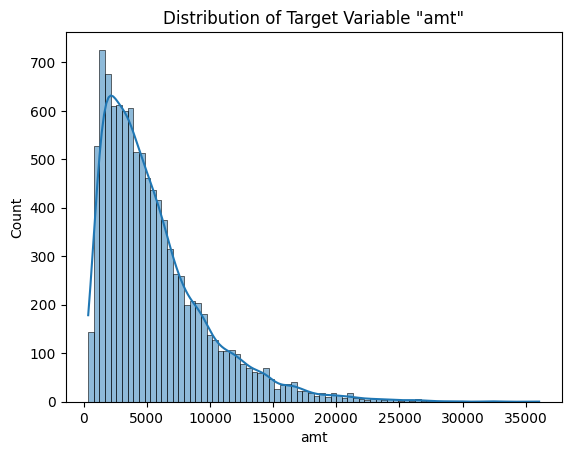

In [7]:
# Correctly subset the DataFrame
purchases_df_target = data[['acct_num', 'unix_time', 'amt', 'category']]

# Add a new column for the transaction month
purchases_df_target['transaction_month'] = pd.to_datetime(purchases_df_target['unix_time'], unit='s').dt.month

# Group by customer and transaction month and aggregate the amounts
grouped_df_target= purchases_df_target.groupby(['acct_num', 'transaction_month']).agg({'amt': 'sum'}).reset_index()

sns.histplot(grouped_df_target['amt'], kde=True)
plt.title('Distribution of Target Variable "amt"')

> Insights: the target variable has a right skew. This may result in difficulties capturing this in the modelling phase of the experiment. Some models may be better equipped to deal with skewed distribtions like this, however a transformation may be required in order to correctly capture the distribution in later experimentation.

this 

In [8]:
# get Desciptive statistics

grouped_df_target[['amt']].describe()


,amt
count,10272.000000
mean,5554.531914
std,4181.942746
min,356.930000
25%,2499.867500
50%,4476.760000
75%,7352.455000
max,36065.460000


> Insights: The descritptive statistics for the target variable when grouped by month and customer show a mean value of approx. $5554.53 per month a median of $4476.76 and a standard deviation of 4181.94

> Considerations: Due to imbalances and a non normal distribution of target variable, data transformations may be necessary. This also may be accounted for by appropriate model selection able to capture this pattern.

> Issues found: NA

<hr>

### C.4 Explore Variables of Interest


#### C.4.a Feature "category"

In [9]:
# explore different categories of transaction 

# Correctly subset the DataFrame
purchases_df_exploration = data[['acct_num', 'unix_time', 'amt', 'category']]

# Add a new column for the transaction month
purchases_df_exploration['transaction_month'] = pd.to_datetime(purchases_df_exploration['unix_time'], unit='s').dt.month

# Group by customer and transaction month and aggregate the amounts
grouped_df_exploration = purchases_df_exploration.groupby(['acct_num', 'transaction_month']).agg({'amt': 'sum'}).reset_index()

# Calculate cumulative count of categories for each customer
purchases_df_exploration['cumulative_category'] = purchases_df_exploration.groupby(['acct_num', 'category']).cumcount() + 1

# Merge grouped DataFrame with purchases DataFrame
merged_df_exploration = pd.merge(grouped_df_exploration, purchases_df_exploration, on=['acct_num', 'transaction_month'], how='left')

# Calculate the most frequently purchased category up to the previous month
merged_df_exploration['cumulative_category_count'] = merged_df_exploration.groupby(['acct_num', 'category'])['cumulative_category'].shift(1)

# Fill NaNs with 0 for cumulative counts
merged_df_exploration['cumulative_category_count'] = merged_df_exploration['cumulative_category_count'].fillna(0)

# Determine the most frequently purchased category prior to the current month
most_purchased_category_prior = merged_df_exploration.groupby(['acct_num', 'transaction_month', 'category'])['cumulative_category_count'].sum().reset_index()
most_purchased_category_prior = most_purchased_category_prior.loc[most_purchased_category_prior.groupby(['acct_num', 'transaction_month'])['cumulative_category_count'].idxmax()]

# Merge back to the merged_df to have the most_purchased_category_prior
merged_df_exploration = pd.merge(merged_df_exploration, most_purchased_category_prior[['acct_num', 'transaction_month', 'category']], on=['acct_num', 'transaction_month'], how='left', suffixes=('', '_most'))

# Rename the merged column to most_purchased_category_prior
merged_df_exploration = merged_df_exploration.rename(columns={'category_most': 'most_purchased_category_prior'})

merged_df_exploration = merged_df_exploration.groupby(['acct_num', 'transaction_month']).agg({ 'most_purchased_category_prior': 'first', 'amt_y': 'sum'}).reset_index()
merged_df_exploration

/tmp/ipykernel_118/3290747554.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  purchases_df_exploration['transaction_month'] = pd.to_datetime(purchases_df_exploration['unix_time'], unit='s').dt.month
/tmp/ipykernel_118/3290747554.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  purchases_df_exploration['cumulative_category'] = purchases_df_exploration.groupby(['acct_num', 'category']).cumcount() + 1


,acct_num,transaction_month,most_purchased_category_prior,amt_y
0,2348758451,1,gas_transport,7043.86
1,2348758451,2,gas_transport,6319.73
2,2348758451,3,grocery_net,5022.04
3,2348758451,4,grocery_pos,5109.51
4,2348758451,5,misc_net,5234.22
...,...,...,...,...
10267,999389892260,8,entertainment,5976.82
10268,999389892260,9,food_dining,5400.96
10269,999389892260,10,health_fitness,6830.67
10270,999389892260,11,home,6372.18


In [10]:
cat_df= merged_df_exploration.groupby(['most_purchased_category_prior']).agg({'amt_y': 'sum'}).reset_index()

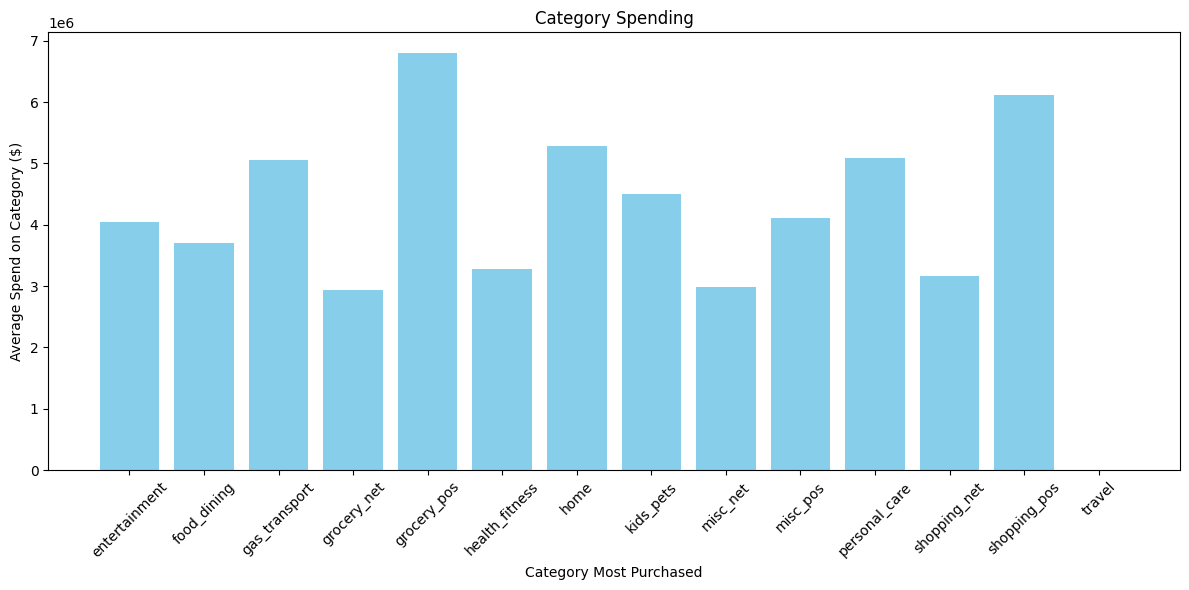

In [11]:
# Plot barchart 
plt.figure(figsize=(12, 6))
plt.bar(cat_df['most_purchased_category_prior'], cat_df['amt_y'], color='skyblue')

plt.xlabel('Category Most Purchased')
plt.ylabel('Average Spend on Category ($)')
plt.title('Category Spending')
plt.xticks(rotation=45)
plt.tight_layout()


> Insights: Customer purchasing behaviours seem to differ when analysing sum of transactions and product categories with the highest frequency

> Considerations: NA

> Issues found: the travel category should be due to significantly low count in the category most purchased column

#### C.4.b Feature "Month"

In [12]:
# Change unix time to datetime and extract date information

data['transaction_dtime']=pd.to_datetime(data['unix_time'],errors='coerce',dayfirst=False, yearfirst=False, utc=False, unit='s', origin='unix', cache=True)

data['transaction_year']=data['transaction_dtime'].dt.year
data['transaction_month']=data['transaction_dtime'].dt.month
data['transaction_day']=data['transaction_dtime'].dt.day

data['transaction_month'].value_counts()

transaction_month
12    126611
7      80702
8      75778
6      75317
5      64753
10     63869
3      62556
4      62047
11     61184
9      61166
2      42970
1      39906
Name: count, dtype: int64

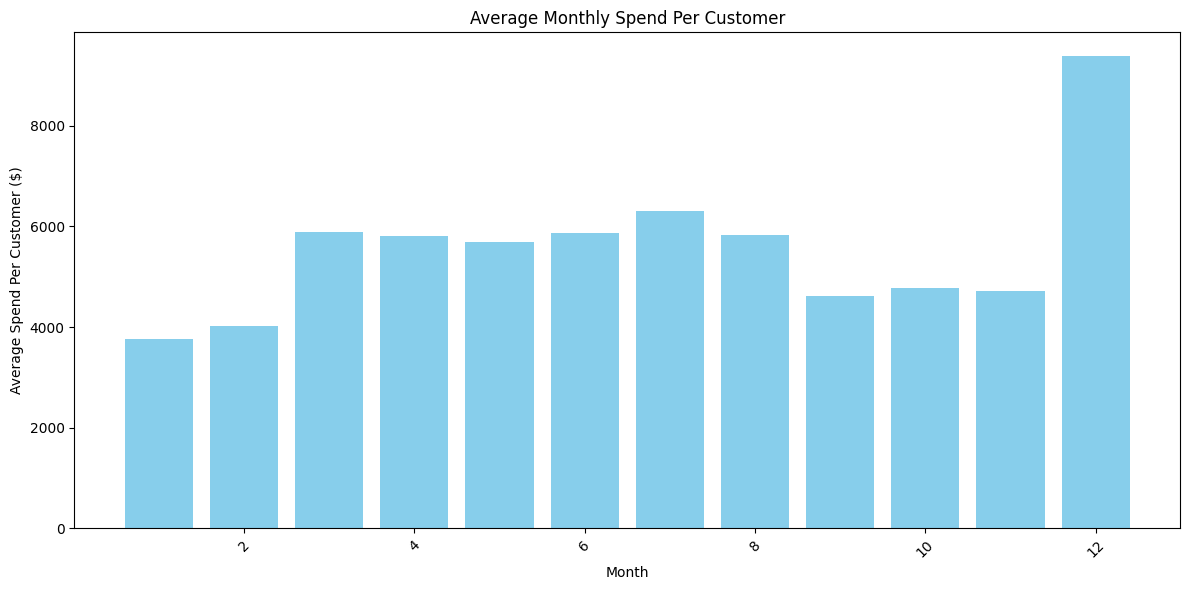

In [13]:
# group data by month  and customer 

grouped_df = data.groupby(['acct_num', 'transaction_month']).agg({'amt': 'sum'}).reset_index()

month_grouped_df = grouped_df.groupby(['transaction_month']).agg({'amt': 'mean'}).reset_index()

# Plot barchart 
plt.figure(figsize=(12, 6))
plt.bar(month_grouped_df['transaction_month'], month_grouped_df['amt'], color='skyblue')

plt.xlabel('Month')
plt.ylabel('Average Spend Per Customer ($)')
plt.title('Average Monthly Spend Per Customer')
plt.xticks(rotation=45)
plt.tight_layout()


> Insights: There appears to be a slight increase in the middle months of the year with a large increase in purchasing during December. These categories demonstrate good seperating in the target variable and it may be a useful feature to include in the modelling. 

> Considerations: NA

> Issues found: No issues found

#### C.4.c Feature "Age and Gender"

In [14]:
# Examining birthdate of customers

# Correctly subset the DataFrame
purchases_df_age = data[['acct_num', 'unix_time', 'amt', 'dob', 'gender']]

# Add a new column for the transaction month
purchases_df_age['transaction_month'] = pd.to_datetime(purchases_df_age['unix_time'], unit='s').dt.month

# Group by customer and transaction month and aggregate the amounts
grouped_df_age = purchases_df_age.groupby(['acct_num']).agg({'amt': 'sum', 'dob': 'first', 'gender': 'first'}).reset_index()

grouped_df_age['age'] = 2022 - pd.to_datetime(grouped_df_age['dob']).dt.year
grouped_df_age

/tmp/ipykernel_118/2004723796.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  purchases_df_age['transaction_month'] = pd.to_datetime(purchases_df_age['unix_time'], unit='s').dt.month


,acct_num,amt,dob,gender,age
0,2348758451,60302.41,1977-05-09,M,45
1,2468061102,67929.07,1958-12-17,F,64
2,3005591724,61139.61,1946-05-23,F,76
3,3418322859,17811.13,2001-07-21,F,21
4,4322238535,23290.62,1930-11-23,M,92
...,...,...,...,...,...
881,994419325906,104484.64,1985-01-13,F,37
882,995642772692,101755.16,1978-10-07,M,44
883,997039479727,98320.76,1974-02-27,M,48
884,997762397943,20875.53,1953-04-06,M,69


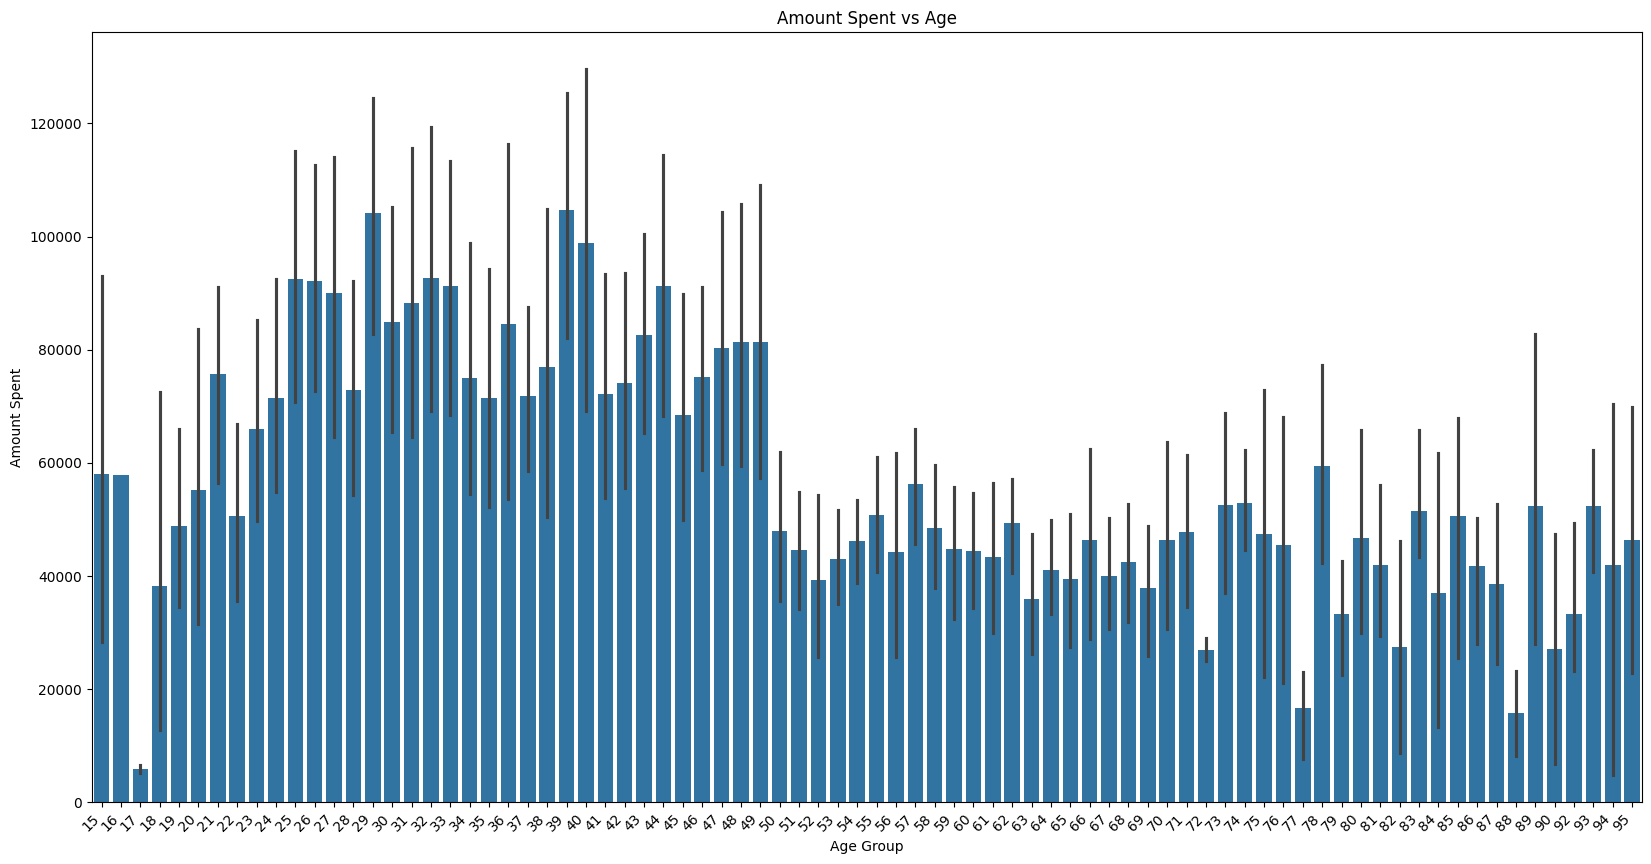

In [15]:
# Plot for amount spent and age
plt.figure(figsize=(20, 10))
sns.barplot(x='age', y='amt', data=grouped_df_age)

# Add titles and labels
plt.title('Amount Spent vs Age')
plt.xlabel('Age Group')
plt.ylabel('Amount Spent')
plt.xticks(rotation=45, ha='right')

# Show the plot
plt.show()


> Insights: Spending by age groups seems to be higher around the 20 to 50 before dropping sharply

> Considerations: NA

> Issues found: No issues found 

<hr>

## D. Feature Selection


In [24]:
feature_selection_executive_summary = 'Use the same list of features from experiment 0.'

> Rationale: The features were selected based off a premlinary assessment of variables performed in section C, however may be further reduced in the following sections to align with the aggregation and goals of the model. 

In [16]:
# check cols 

data.columns

Index(['cc_num', 'acct_num', 'trans_num', 'unix_time', 'category', 'amt',
       'is_fraud', 'merchant', 'merch_lat', 'merch_long', 'source_file',
       'index', 'combined_source_file', 'ssn', 'first', 'last', 'gender',
       'street', 'city', 'state', 'zip', 'lat', 'long', 'city_pop', 'job',
       'dob', 'transaction_dtime', 'transaction_year', 'transaction_month',
       'transaction_day'],
      dtype='object')

In [17]:
# make list of selected features and create new df
features_list = ['acct_num', 'category', 'amt',
       'is_fraud',  'gender','city_pop', 'job','dob', 'transaction_month']

data_selected = data[features_list]

> Results: dataset with selected features created successfully 

<hr>

## E. Data Preparation

In [27]:
data_preparation_executive_summary = 'The goal of this section is to clean the data, and prepare it for modelling. This involves removing invalid records and data aggregation. '

### E.1 Fixing "Fraudulent Transactions"

> Rationale: Fraudulent transactions are not representative of the target we are trying to assess and will provide noise to the model

In [18]:
# reomve records where fraud is 1 then drop col 

data_selected = data_selected[data_selected['is_fraud'] == 0]
data_selected.drop('is_fraud',axis=1,inplace=True)

> Results: Fraudulent transactions removed successfully

<hr>

### E.2 Fixing "Data Aggregation"

> Rationale: The transactional data is not appropriate for modelling monthly spend, as as result the data must be grouped by both customer using the acct_num variable and transaction month. This also involves removing records where customers do not have data across all 12 months.

In [20]:
# group data by month and customer  

customer_month_data = data.groupby(['acct_num', 'transaction_month']).agg({'amt': 'sum', 'gender': 'first', 'city_pop': 'first', 'job': 'first', 'dob': 'first'}).reset_index()
customer_month_data

,acct_num,transaction_month,amt,gender,city_pop,job,dob
0,2348758451,1,7043.86,M,478127,"Surveyor, minerals",1977-05-09
1,2348758451,2,6319.73,M,478127,"Surveyor, minerals",1977-05-09
2,2348758451,3,5022.04,M,478127,"Surveyor, minerals",1977-05-09
3,2348758451,4,5109.51,M,478127,"Surveyor, minerals",1977-05-09
4,2348758451,5,5234.22,M,478127,"Surveyor, minerals",1977-05-09
...,...,...,...,...,...,...,...
10267,999389892260,8,5976.82,M,20714,Phytotherapist,1987-08-06
10268,999389892260,9,5400.96,M,20714,Phytotherapist,1987-08-06
10269,999389892260,10,6830.67,M,20714,Phytotherapist,1987-08-06
10270,999389892260,11,6372.18,M,20714,Phytotherapist,1987-08-06


In [21]:
# check that each customer has data for 12 months

pd.DataFrame(customer_month_data['acct_num'].value_counts())

,count
acct_num,
2348758451,12
667232262429,12
659250094381,12
659387322373,12
659584348138,12
...,...
719159529356,1
594076940942,1
425242091796,1


In [22]:
# check value counts to ensure all customers have records across all 12 months 

value_counts = customer_month_data['acct_num'].value_counts()

customer_month_data = customer_month_data[customer_month_data['acct_num'].isin(value_counts[value_counts == 12].index)]
pd.DataFrame(customer_month_data['acct_num'].value_counts())

,count
acct_num,
2348758451,12
661208661076,12
662295995829,12
662887798281,12
664177281037,12
...,...
328958815917,12
330749144229,12
330792868853,12


> Results: Data successfully aggregated and invalid records removed 

<hr>

<hr>

## F. Feature Engineering

In [33]:
feature_engineering_executive_summary = 'This section focuses on data mining and the creation and scaling of variables which may be insightful appropriate for modelling using regression. In order that the model has efficacy to real world data/unseen data, one of the constraints chosen to be placed on the dataset is to only train it using variables unseen prior to the month being predicted. For this reason, the features engineered are formulated in a way which takes into account the target month and only aggregates information from prior to this month. '

### F.1 Amount spent month prior 

> Rationale: past purchasing behaviour can be used as a feature for future predications. the following code block calculates the amount spent by the customer for the month prior. 

In [23]:
# amount spent last month 

customer2 = customer_month_data.sort_values(by=['acct_num','transaction_month'])
customer2['last_amt'] = customer2.groupby('acct_num')['amt'].shift(1)
customer2

,acct_num,transaction_month,amt,gender,city_pop,job,dob,last_amt
0,2348758451,1,7043.86,M,478127,"Surveyor, minerals",1977-05-09,NaN
1,2348758451,2,6319.73,M,478127,"Surveyor, minerals",1977-05-09,7043.86
2,2348758451,3,5022.04,M,478127,"Surveyor, minerals",1977-05-09,6319.73
3,2348758451,4,5109.51,M,478127,"Surveyor, minerals",1977-05-09,5022.04
4,2348758451,5,5234.22,M,478127,"Surveyor, minerals",1977-05-09,5109.51
...,...,...,...,...,...,...,...,...
10267,999389892260,8,5976.82,M,20714,Phytotherapist,1987-08-06,4870.41
10268,999389892260,9,5400.96,M,20714,Phytotherapist,1987-08-06,5976.82
10269,999389892260,10,6830.67,M,20714,Phytotherapist,1987-08-06,5400.96
10270,999389892260,11,6372.18,M,20714,Phytotherapist,1987-08-06,6830.67


> Results: prior month spend calculated successfully 

### F.2 Average spend to date

> Rationale: past purchasing behaviour can be used as a feature for future predications. the following code block calculates the average amount spent by the customer prior to the target month by dividing the total prior spend by number of prior months. 

In [24]:
# calculate average spend to date for customer 

customer2['cumulative_sum'] = customer2.groupby('acct_num')['amt'].cumsum() - customer2['amt'] 

customer2['cumulative_count'] = customer2.groupby('acct_num').cumcount() 

# Calculate average amount spent per month prior to the current month 
customer2['average_amt_prior'] = customer2['cumulative_sum'] / customer2['cumulative_count']
customer2

,acct_num,transaction_month,amt,gender,city_pop,job,dob,last_amt,cumulative_sum,cumulative_count,average_amt_prior
0,2348758451,1,7043.86,M,478127,"Surveyor, minerals",1977-05-09,NaN,0.00,0,NaN
1,2348758451,2,6319.73,M,478127,"Surveyor, minerals",1977-05-09,7043.86,7043.86,1,7043.860000
2,2348758451,3,5022.04,M,478127,"Surveyor, minerals",1977-05-09,6319.73,13363.59,2,6681.795000
3,2348758451,4,5109.51,M,478127,"Surveyor, minerals",1977-05-09,5022.04,18385.63,3,6128.543333
4,2348758451,5,5234.22,M,478127,"Surveyor, minerals",1977-05-09,5109.51,23495.14,4,5873.785000
...,...,...,...,...,...,...,...,...,...,...,...
10267,999389892260,8,5976.82,M,20714,Phytotherapist,1987-08-06,4870.41,37047.05,7,5292.435714
10268,999389892260,9,5400.96,M,20714,Phytotherapist,1987-08-06,5976.82,43023.87,8,5377.983750
10269,999389892260,10,6830.67,M,20714,Phytotherapist,1987-08-06,5400.96,48424.83,9,5380.536667
10270,999389892260,11,6372.18,M,20714,Phytotherapist,1987-08-06,6830.67,55255.50,10,5525.550000


> Results: average prior monthly spend calculated successfully 

### F.3 Birth month 

> Rationale: Intuitively it can be assumed that during ones birth month that a customer will spent more money. 

In [25]:
# bullion for is birthday month 

customer2['isbirthmoth'] = np.where(customer2['transaction_month'] == pd.to_datetime(customer2['dob']).dt.month, 1, 0)
customer2

,acct_num,transaction_month,amt,gender,city_pop,job,dob,last_amt,cumulative_sum,cumulative_count,average_amt_prior,isbirthmoth
0,2348758451,1,7043.86,M,478127,"Surveyor, minerals",1977-05-09,NaN,0.00,0,NaN,0
1,2348758451,2,6319.73,M,478127,"Surveyor, minerals",1977-05-09,7043.86,7043.86,1,7043.860000,0
2,2348758451,3,5022.04,M,478127,"Surveyor, minerals",1977-05-09,6319.73,13363.59,2,6681.795000,0
3,2348758451,4,5109.51,M,478127,"Surveyor, minerals",1977-05-09,5022.04,18385.63,3,6128.543333,0
4,2348758451,5,5234.22,M,478127,"Surveyor, minerals",1977-05-09,5109.51,23495.14,4,5873.785000,1
...,...,...,...,...,...,...,...,...,...,...,...,...
10267,999389892260,8,5976.82,M,20714,Phytotherapist,1987-08-06,4870.41,37047.05,7,5292.435714,1
10268,999389892260,9,5400.96,M,20714,Phytotherapist,1987-08-06,5976.82,43023.87,8,5377.983750,0
10269,999389892260,10,6830.67,M,20714,Phytotherapist,1987-08-06,5400.96,48424.83,9,5380.536667,0
10270,999389892260,11,6372.18,M,20714,Phytotherapist,1987-08-06,6830.67,55255.50,10,5525.550000,0


> Results: Birth month column created successfully 

### F.4 Age 

> Rationale: As demonstrated by the EDA in section C, total spend categories for age groups differ and as a result it has been calculated and included as a feature for modelling. 

In [26]:
# calculate age at time of purchase 

customer2['age'] = 2022 - pd.to_datetime(customer2['dob']).dt.year
customer2

,acct_num,transaction_month,amt,gender,city_pop,job,dob,last_amt,cumulative_sum,cumulative_count,average_amt_prior,isbirthmoth,age
0,2348758451,1,7043.86,M,478127,"Surveyor, minerals",1977-05-09,NaN,0.00,0,NaN,0,45
1,2348758451,2,6319.73,M,478127,"Surveyor, minerals",1977-05-09,7043.86,7043.86,1,7043.860000,0,45
2,2348758451,3,5022.04,M,478127,"Surveyor, minerals",1977-05-09,6319.73,13363.59,2,6681.795000,0,45
3,2348758451,4,5109.51,M,478127,"Surveyor, minerals",1977-05-09,5022.04,18385.63,3,6128.543333,0,45
4,2348758451,5,5234.22,M,478127,"Surveyor, minerals",1977-05-09,5109.51,23495.14,4,5873.785000,1,45
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10267,999389892260,8,5976.82,M,20714,Phytotherapist,1987-08-06,4870.41,37047.05,7,5292.435714,1,35
10268,999389892260,9,5400.96,M,20714,Phytotherapist,1987-08-06,5976.82,43023.87,8,5377.983750,0,35
10269,999389892260,10,6830.67,M,20714,Phytotherapist,1987-08-06,5400.96,48424.83,9,5380.536667,0,35
10270,999389892260,11,6372.18,M,20714,Phytotherapist,1987-08-06,6830.67,55255.50,10,5525.550000,0,35


> Results: Age created successfully 

### F.5 One-hot encoding for gender 

> Rationale: Gender needs to be converted to a binary variable in order for quantitative analysis as in the models suggested. 

In [27]:
# convert gender to binary column 

customer2['is_male'] = np.where(customer2['gender'] == 'M', 1, 0)
customer2

,acct_num,transaction_month,amt,gender,city_pop,job,dob,last_amt,cumulative_sum,cumulative_count,average_amt_prior,isbirthmoth,age,is_male
0,2348758451,1,7043.86,M,478127,"Surveyor, minerals",1977-05-09,NaN,0.00,0,NaN,0,45,1
1,2348758451,2,6319.73,M,478127,"Surveyor, minerals",1977-05-09,7043.86,7043.86,1,7043.860000,0,45,1
2,2348758451,3,5022.04,M,478127,"Surveyor, minerals",1977-05-09,6319.73,13363.59,2,6681.795000,0,45,1
3,2348758451,4,5109.51,M,478127,"Surveyor, minerals",1977-05-09,5022.04,18385.63,3,6128.543333,0,45,1
4,2348758451,5,5234.22,M,478127,"Surveyor, minerals",1977-05-09,5109.51,23495.14,4,5873.785000,1,45,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10267,999389892260,8,5976.82,M,20714,Phytotherapist,1987-08-06,4870.41,37047.05,7,5292.435714,1,35,1
10268,999389892260,9,5400.96,M,20714,Phytotherapist,1987-08-06,5976.82,43023.87,8,5377.983750,0,35,1
10269,999389892260,10,6830.67,M,20714,Phytotherapist,1987-08-06,5400.96,48424.83,9,5380.536667,0,35,1
10270,999389892260,11,6372.18,M,20714,Phytotherapist,1987-08-06,6830.67,55255.50,10,5525.550000,0,35,1


> Results: Gender successfully converted to a binary numeric datatype

### F.6 Most purchased category prior 

> Rationale:  Results from the EDA suggest that there is interesting variance in total spend, when comparing the categories in which customers spend the most money. This will be further investigated in the modelling phase by creating a feature which identifies the most frequent category of purchase for that customer.  

In [28]:
# Correctly subset the DataFrame
purchases_df = data[['acct_num', 'unix_time', 'amt', 'category']]

# Add a new column for the transaction month
purchases_df['transaction_month'] = pd.to_datetime(purchases_df['unix_time'], unit='s').dt.month

# Group by customer and transaction month and aggregate the amounts
grouped_df = purchases_df.groupby(['acct_num', 'transaction_month']).agg({'amt': 'sum'}).reset_index()

# Calculate cumulative count of categories for each customer
purchases_df['cumulative_category'] = purchases_df.groupby(['acct_num', 'category']).cumcount() + 1

# Merge grouped DataFrame with purchases DataFrame
merged_df = pd.merge(grouped_df, purchases_df, on=['acct_num', 'transaction_month'], how='left')

# Calculate the most frequently purchased category up to the previous month
merged_df['cumulative_category_count'] = merged_df.groupby(['acct_num', 'category'])['cumulative_category'].shift(1)

# Fill missingvalues with 0 for cumulative counts
merged_df['cumulative_category_count'] = merged_df['cumulative_category_count'].fillna(0)

# Determine the most frequently purchased category prior to the current month
most_purchased_category_prior = merged_df.groupby(['acct_num', 'transaction_month', 'category'])['cumulative_category_count'].sum().reset_index()
most_purchased_category_prior = most_purchased_category_prior.loc[most_purchased_category_prior.groupby(['acct_num', 'transaction_month'])['cumulative_category_count'].idxmax()]

# Merge back to the merged_df to have the most_purchased_category_prior
merged_df = pd.merge(merged_df, most_purchased_category_prior[['acct_num', 'transaction_month', 'category']], on=['acct_num', 'transaction_month'], how='left', suffixes=('', '_most'))

# Rename the merged column 
merged_df = merged_df.rename(columns={'category_most': 'most_purchased_category_prior'})

merged_df = merged_df.groupby(['acct_num', 'transaction_month']).agg({ 'most_purchased_category_prior': 'first'}).reset_index()
merged_df

/tmp/ipykernel_118/1595493003.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  purchases_df['transaction_month'] = pd.to_datetime(purchases_df['unix_time'], unit='s').dt.month
/tmp/ipykernel_118/1595493003.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  purchases_df['cumulative_category'] = purchases_df.groupby(['acct_num', 'category']).cumcount() + 1


,acct_num,transaction_month,most_purchased_category_prior
0,2348758451,1,gas_transport
1,2348758451,2,gas_transport
2,2348758451,3,grocery_net
3,2348758451,4,grocery_pos
4,2348758451,5,misc_net
...,...,...,...
10267,999389892260,8,entertainment
10268,999389892260,9,food_dining
10269,999389892260,10,health_fitness
10270,999389892260,11,home


In [29]:
# join with main df

customer2 = pd.merge(customer2, merged_df, on=['acct_num', 'transaction_month'], how='left')


In [30]:
customer2['most_purchased_category_prior'].value_counts()

most_purchased_category_prior
gas_transport     1511
grocery_pos       1273
home              1033
shopping_pos      1024
food_dining        778
kids_pets          749
misc_pos           722
health_fitness     706
entertainment      646
personal_care      531
grocery_net        462
shopping_net       437
misc_net           363
travel               1
Name: count, dtype: int64

In [31]:
# drop row where travel is the most purchased category

customer2 = customer2[customer2['most_purchased_category_prior'] != 'travel']
customer2['most_purchased_category_prior'].value_counts()

most_purchased_category_prior
gas_transport     1511
grocery_pos       1273
home              1033
shopping_pos      1024
food_dining        778
kids_pets          749
misc_pos           722
health_fitness     706
entertainment      646
personal_care      531
grocery_net        462
shopping_net       437
misc_net           363
Name: count, dtype: int64

> Results: Most purchased category column successfully created and 'travel' category record removed due to insufficient volume of results

### F.7 Drop irrelevant columns 

> Rationale: Some columns used for calculations are no longer necessary for modelling and dropped from the dataframe.

In [32]:
# drop unnecssary cols 

customer2.drop(['dob', 'cumulative_sum', 'cumulative_count', 'job', 'acct_num', 'gender'], axis=1, inplace=True)
customer2

,transaction_month,amt,city_pop,last_amt,average_amt_prior,isbirthmoth,age,is_male,most_purchased_category_prior
0,1,7043.86,478127,NaN,NaN,0,45,1,gas_transport
1,2,6319.73,478127,7043.86,7043.860000,0,45,1,gas_transport
2,3,5022.04,478127,6319.73,6681.795000,0,45,1,grocery_net
3,4,5109.51,478127,5022.04,6128.543333,0,45,1,grocery_pos
4,5,5234.22,478127,5109.51,5873.785000,1,45,1,misc_net
...,...,...,...,...,...,...,...,...,...
10231,8,5976.82,20714,4870.41,5292.435714,1,35,1,entertainment
10232,9,5400.96,20714,5976.82,5377.983750,0,35,1,food_dining
10233,10,6830.67,20714,5400.96,5380.536667,0,35,1,health_fitness
10234,11,6372.18,20714,6830.67,5525.550000,0,35,1,home


> Results: Unnecessary columns successfully removed 

### F.8 Drop records from January

> Rationale: as last purchase month requires previous data from the month immediately prior, and the dataset only contains results from one year, the first month (Jan) must removed in order to prevent Nan results from the dataset for this variable. 

In [33]:
# Drop all columns from Jan

customer2 = customer2[customer2['transaction_month'] != 1]
customer2

,transaction_month,amt,city_pop,last_amt,average_amt_prior,isbirthmoth,age,is_male,most_purchased_category_prior
1,2,6319.73,478127,7043.86,7043.860000,0,45,1,gas_transport
2,3,5022.04,478127,6319.73,6681.795000,0,45,1,grocery_net
3,4,5109.51,478127,5022.04,6128.543333,0,45,1,grocery_pos
4,5,5234.22,478127,5109.51,5873.785000,1,45,1,misc_net
5,6,4218.30,478127,5234.22,5745.872000,0,45,1,misc_pos
...,...,...,...,...,...,...,...,...,...
10231,8,5976.82,20714,4870.41,5292.435714,1,35,1,entertainment
10232,9,5400.96,20714,5976.82,5377.983750,0,35,1,food_dining
10233,10,6830.67,20714,5400.96,5380.536667,0,35,1,health_fitness
10234,11,6372.18,20714,6830.67,5525.550000,0,35,1,home


> Results: Records from Jan successfully removed. 

### F.9 One-hot encoding for most purchased category

> Rationale: Categorical variable for the created column most purchased category prior need to be one hot encoded for quantitative analysis 

In [34]:
# perform one hot encoding for most_purchased_category_prior

customer3 = pd.get_dummies(customer2, columns=['most_purchased_category_prior'], drop_first=True).astype(int)
customer3

,transaction_month,amt,city_pop,last_amt,average_amt_prior,isbirthmoth,age,is_male,most_purchased_category_prior_food_dining,most_purchased_category_prior_gas_transport,most_purchased_category_prior_grocery_net,most_purchased_category_prior_grocery_pos,most_purchased_category_prior_health_fitness,most_purchased_category_prior_home,most_purchased_category_prior_kids_pets,most_purchased_category_prior_misc_net,most_purchased_category_prior_misc_pos,most_purchased_category_prior_personal_care,most_purchased_category_prior_shopping_net,most_purchased_category_prior_shopping_pos
1,2,6319,478127,7043,7043,0,45,1,0,1,0,0,0,0,0,0,0,0,0,0
2,3,5022,478127,6319,6681,0,45,1,0,0,1,0,0,0,0,0,0,0,0,0
3,4,5109,478127,5022,6128,0,45,1,0,0,0,1,0,0,0,0,0,0,0,0
4,5,5234,478127,5109,5873,1,45,1,0,0,0,0,0,0,0,1,0,0,0,0
5,6,4218,478127,5234,5745,0,45,1,0,0,0,0,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10231,8,5976,20714,4870,5292,1,35,1,0,0,0,0,0,0,0,0,0,0,0,0
10232,9,5400,20714,5976,5377,0,35,1,1,0,0,0,0,0,0,0,0,0,0,0
10233,10,6830,20714,5400,5380,0,35,1,0,0,0,0,1,0,0,0,0,0,0,0
10234,11,6372,20714,6830,5525,0,35,1,0,0,0,0,0,1,0,0,0,0,0,0


> Results: Most frequently purchased prior successfully one hot encoded 

### F.10 check for missing values in final dataset 

> Rationale: Final check to ensure that there are no NaN values in the dataset after feature engineering 

In [35]:
# check again for NaN values 

customer3.isna().sum()

transaction_month                               0
amt                                             0
city_pop                                        0
last_amt                                        0
average_amt_prior                               0
isbirthmoth                                     0
age                                             0
is_male                                         0
most_purchased_category_prior_food_dining       0
most_purchased_category_prior_gas_transport     0
most_purchased_category_prior_grocery_net       0
most_purchased_category_prior_grocery_pos       0
most_purchased_category_prior_health_fitness    0
most_purchased_category_prior_home              0
most_purchased_category_prior_kids_pets         0
most_purchased_category_prior_misc_net          0
most_purchased_category_prior_misc_pos          0
most_purchased_category_prior_personal_care     0
most_purchased_category_prior_shopping_net      0
most_purchased_category_prior_shopping_pos      0


> Results: No missing values 

### F.11 Reset index for final dataset 

> Rationale: Reset index for final dataset after all features are successfully created and all irrelevant records are removed 

In [36]:
# reset index 

customer4 = customer3.reset_index(drop=True)
customer4

,transaction_month,amt,city_pop,last_amt,average_amt_prior,isbirthmoth,age,is_male,most_purchased_category_prior_food_dining,most_purchased_category_prior_gas_transport,most_purchased_category_prior_grocery_net,most_purchased_category_prior_grocery_pos,most_purchased_category_prior_health_fitness,most_purchased_category_prior_home,most_purchased_category_prior_kids_pets,most_purchased_category_prior_misc_net,most_purchased_category_prior_misc_pos,most_purchased_category_prior_personal_care,most_purchased_category_prior_shopping_net,most_purchased_category_prior_shopping_pos
0,2,6319,478127,7043,7043,0,45,1,0,1,0,0,0,0,0,0,0,0,0,0
1,3,5022,478127,6319,6681,0,45,1,0,0,1,0,0,0,0,0,0,0,0,0
2,4,5109,478127,5022,6128,0,45,1,0,0,0,1,0,0,0,0,0,0,0,0
3,5,5234,478127,5109,5873,1,45,1,0,0,0,0,0,0,0,1,0,0,0,0
4,6,4218,478127,5234,5745,0,45,1,0,0,0,0,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9377,8,5976,20714,4870,5292,1,35,1,0,0,0,0,0,0,0,0,0,0,0,0
9378,9,5400,20714,5976,5377,0,35,1,1,0,0,0,0,0,0,0,0,0,0,0
9379,10,6830,20714,5400,5380,0,35,1,0,0,0,0,1,0,0,0,0,0,0,0
9380,11,6372,20714,6830,5525,0,35,1,0,0,0,0,0,1,0,0,0,0,0,0


> Results: Index successfully reset to new final dataset.  

<hr>

<hr>

## G. Data Preparation for Modeling

In [49]:
modeling_preparation_executive_summary = 'This section involves splitting the dataset into training testing and validation sets to prepare for the modelling section of the experiment. It also involves scaling the predictor variables for analysis using training data, as some regression models are distance based and require standardisation in order to accurately capture the data and values of the coefficients. '

### G.1 Split Datasets

> Rationale: Use train test split to split data twice into training, validation and testing splits and save to new variables

In [37]:
# import train test split from sklearn

from sklearn.model_selection import train_test_split


In [38]:
# Make first split to get training and temp split
train_data, temp_data = sklearn.model_selection.train_test_split(customer4, test_size=0.4, random_state=101)

# make second split to get validation and test sets
test_data, validation_data = sklearn.model_selection.train_test_split(customer4, test_size=0.5, random_state=101)

X_train = train_data.copy()
X_val = validation_data.copy()
X_test = test_data.copy()

# use pop to get target variable out 

y_train = X_train.pop('amt')
y_val = X_val.pop('amt')
y_test = X_test.pop('amt')

> Results: All three sets successfully created 

<hr>

### G.2 Data Transformation "Standardisation"

> Rationale: some forms of modelling require standardisation in order to correctly make predictions 

In [39]:
# Separerate categorical and numercal features for standard scaling

cat_features = ['most_purchased_category_prior_food_dining',
       'most_purchased_category_prior_gas_transport',
       'most_purchased_category_prior_grocery_net',
       'most_purchased_category_prior_grocery_pos',
       'most_purchased_category_prior_health_fitness',
       'most_purchased_category_prior_home',
       'most_purchased_category_prior_kids_pets',
       'most_purchased_category_prior_misc_net',
       'most_purchased_category_prior_misc_pos',
       'most_purchased_category_prior_personal_care',
       'most_purchased_category_prior_shopping_net',
       'most_purchased_category_prior_shopping_pos', 
       'is_male',
       'isbirthmoth']
numerical_features = ['transaction_month', 'city_pop', 'last_amt', 'average_amt_prior', 'age']

#extract categorical features:

X_train_cat = X_train[cat_features].copy()
X_val_cat = X_val[cat_features].copy()
X_test_cat = X_test[cat_features].copy()

#extract numerical features:

X_train_num = X_train[numerical_features].copy()
X_val_num = X_val[numerical_features].copy()
X_test_num = X_test[numerical_features].copy()


In [40]:
#standardize numerical features:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler().set_output(transform="pandas")
scaler.fit(X_train_num)

X_train_num_transformed=scaler.transform(X_train_num)
X_val_num_transformed=scaler.transform(X_val_num)
X_test_num_transformed=scaler.transform(X_test_num)

# create  the final datasets for SVC modelling:
X_train_scaled = pd.concat([X_train_num_transformed,X_train_cat], axis=1)
X_val_scaled = pd.concat([X_val_num_transformed,X_val_cat], axis=1)
X_test_scaled = pd.concat([X_test_num_transformed,X_test_cat], axis=1)

> Results: data successfully scaled and saved into new variables  

<hr>

## H. Assess Baseline Model

In [54]:
baseline_model_executive_summary = 'The goal of this section is to create a baseline model to compare future models and iterations with in order to determine the performance of them. Metrics for determining the success of the model and measuring its performance are also defined and imported in this section. '

### H.1 Simulate Predictions with Baseline Model

> Rationale: Create a baseline model containing the mean value for the training set. 

In [41]:
# Define central value for baseline model
# calculate mean for training data 

y_central = y_train.mean()

In [42]:
# fill array with predictions based off mean 

training_preds = np.full(y_train.shape, y_central)

### H.2 Selection of Performance Metrics

> Rationale: MAE and MSE are both insightful  metrics for determining the performance of regression models. MAE is more interpretable however MSE is more sensitive to high residuals . By reporting both a nuanced understanding of the models performance can be ascertained. 

In [43]:
# import metrics for evaluation


from sklearn.metrics import mean_squared_error as mse
from sklearn.metrics import mean_absolute_error as mae

### H.3 Baseline Model Performance

In [44]:
# get perfromance metrics for the baseline model 

print(mse(y_train, training_preds, squared=False))
print(mae(y_train, training_preds))

4202.94701219551
3149.7184351738388


> Results: Baseline model performance successfully run 

## I. Train Machine Learning Model

In [59]:
train_model_executive_summary = 'The goal of this section is to train several regression models and tune there hyperparameters resulting in the best performance in the validation dataset. The best model and hyperparameters will then be selected for use on the testing dataset. Three types of models we be tested 1) a lasso regression model, 2) a Random Forest model and 3) a MLP Regressor Model. '

### I.1 Import Algorithm

> Rationale: three models will be tested with different hyperparameters. 

In [45]:
# import models from sklearn

from sklearn.linear_model import Lasso 
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor

<hr>

### I.2 Set Hyperparameters

> Rationale: Hyperparamteres to be tested are located above each of the models tested in section I.3

<hr>

### I.3 Fit Model

### Lasso Model 

In [62]:
# set hyperparamteres for Lasso model 

lasso_alphalevels = [0.001, 0.01, 0.5, 1.0, 5.0, 10.0, 20.0, 30.0, 35.0, 40.0, 45.0, 50.0, 55.0, 100.0]

# Create empty variables and lists to hold best resutls  

lasso_results = [] 
lasso_best_params = [] 
lasso_best_mse = float('inf') 
lasso_best_mae = float('inf')


In [63]:
# Loop through hyperparameters for lasso model and record perforomance metrics and best resutls 

for alpha in lasso_alphalevels:
    model= Lasso(alpha=alpha)
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_val_scaled)
    mse_val = mse(y_val, preds, squared=False)
    mae_val = mae(y_val, preds)
    lasso_results.append((alpha, mse_val, mae_val))
    if mae_val < lasso_best_mae:
        lasso_best_mae = mae_val
        lasso_best_params = alpha

In [64]:
# print best resutls and store resutls as DF  

print("Best Parameters:", lasso_best_params) 
print("Best MAE:", lasso_best_mae)
lasso_results_df = pd.DataFrame(lasso_results, columns=['alpha', 'mse', 'mae'])

Best Parameters: 5.0
Best MAE: 1592.1562365561967


### Random Forest Model 

In [65]:
# set hyperparamteres for Lasso model 

n_estimators_values = [10, 50, 100] 
max_depth_values = [None, 5, 10] 
min_samples_split_values = [2, 5, 10]

# create empty variables and lists to hold best resutls

rf_results = [] 
rf_best_params = [] 
rf_best_mse = float('inf') 
rf_best_mae = float('inf')

In [66]:
# Loop through hyperparameters for Random Forest model and record perforomance metrics and best resutls 

test_num = 1
for n_estimators in n_estimators_values:
    for max_depth in max_depth_values:
        for min_samples_split in min_samples_split_values:
            print(f'executing test {test_num}')
            model = RandomForestRegressor(n_estimators=n_estimators, max_depth=max_depth, min_samples_split=min_samples_split, random_state=8)
            model.fit(X_train_scaled, y_train)
            y_pred = model.predict(X_val_scaled)
            mse_val = mse(y_val, y_pred, squared=False)
            mae_val = mae(y_val, y_pred)
            rf_results.append({'n_estimators': n_estimators, 'max_depth': max_depth, 'min_samples_split': min_samples_split, 'mse': mse, 'mae': mae})
            test_num += 1
            if mae_val < rf_best_mae:
                rf_best_params = {'n_estimators': n_estimators, 'max_depth': max_depth, 'min_samples_split': min_samples_split}
                rf_best_mae = mae_val



executing test 1
executing test 2
executing test 3
executing test 4
executing test 5
executing test 6
executing test 7
executing test 8
executing test 9
executing test 10
executing test 11
executing test 12
executing test 13
executing test 14
executing test 15
executing test 16
executing test 17
executing test 18
executing test 19
executing test 20
executing test 21
executing test 22
executing test 23
executing test 24
executing test 25
executing test 26
executing test 27


In [67]:
# print best resutls and patameters

print("Best Parameters:", rf_best_params)
print("Best MAE:", rf_best_mae)


Best Parameters: {'n_estimators': 100, 'max_depth': None, 'min_samples_split': 2}
Best MAE: 1216.3745725858025


### Neural Network 

In [72]:
# List of hyperparameters to try
hidden_layer_sizes_values = [(50,), (100,), (50, 50), (100, 100)]
activation_values = ['relu', 'tanh']
alpha_values = [0.0001, 0.001, 0.01]
learning_rate_values = ['constant', 'adaptive']

test_num = 1

# Initialize lists to store results
results = []
best_params = {}
best_mse = float('inf')
best_mae = float('inf')

# Loop through hyperparameter combinations
for hidden_layer_sizes in hidden_layer_sizes_values:
    for activation in activation_values:
        for alpha in alpha_values:
            for learning_rate in learning_rate_values:
                print(f'executing test {test_num}')
                model = MLPRegressor(hidden_layer_sizes=hidden_layer_sizes, activation=activation, 
                                        solver='adam', alpha=alpha, learning_rate=learning_rate, 
                                        max_iter=1000, random_state=1, early_stopping=True)
                model.fit(X_train_scaled, y_train)
                
                y_pred = model.predict(X_val_scaled)
                
                mse_val = mse(y_val, y_pred)
                mae_val = mae(y_val, y_pred)
                
                results.append({'hidden_layer_sizes': hidden_layer_sizes, 'activation': activation, 
                                 'alpha': alpha, 'learning_rate': learning_rate, 
                                 'mse': mse_val, 'mae': mae_val})
                test_num += 1

                if mae_val < best_mae:
                    best_params = {'hidden_layer_sizes': hidden_layer_sizes, 'activation': activation, 
                                    'alpha': alpha, 'learning_rate': learning_rate}
                    best_mae = mae_val




executing test 1
executing test 2
executing test 3
executing test 4
executing test 5
executing test 6
executing test 7
/root/venv/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
executing test 8
/root/venv/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
executing test 9
/root/venv/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
executing test 10
/root/venv/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum

In [73]:
# Print best results and parameters  
print("Best Parameters:", best_params)
print("Best MAE:", best_mae)

Best Parameters: {'hidden_layer_sizes': (100, 100), 'activation': 'relu', 'alpha': 0.0001, 'learning_rate': 'constant'}
Best MAE: 1409.328146166228


<hr>

### I.4 Model Technical Performance

In [46]:
# assess performance of all models of test set 

# best Lasso model
best_lasso = Lasso(alpha=5.0)
best_lasso.fit(X_train_scaled, y_train)
lasso_preds = best_lasso.predict(X_test_scaled)

# best Random Forest Model
best_rf = RandomForestRegressor(n_estimators=100, max_depth=None, min_samples_split=2, random_state=8)
best_rf.fit(X_train_scaled, y_train)
rf_preds = best_rf.predict(X_test_scaled)

# best MLP Regeressor Model
best_MLP = MLPRegressor(hidden_layer_sizes=(100,100), activation='relu', 
                            solver='adam', alpha=0.0001, learning_rate='constant', 
                            max_iter=1000, random_state=1, early_stopping=True)
best_MLP.fit(X_train_scaled, y_train)
MLP_preds = best_MLP.predict(X_test_scaled)

In [47]:
# get test scores for each model on test set 

print(f'Test Lasso MSE: {mse(y_test, lasso_preds, squared=False)}')
print(f'Test Lasso MAE: {mae(y_test, lasso_preds)}')

print(f'Test RF MSE: {mse(y_test, rf_preds, squared=False)}')
print(f'Test RF MAE: {mae(y_test, rf_preds)}')

print(f'Test MLP MSE: {mse(y_test, MLP_preds, squared=False)}')
print(f'Test MLP MAE: {mae(y_test, MLP_preds)}')


Test Lasso MSE: 2318.9265884818237
Test Lasso MAE: 1568.7783966924487
Test RF MSE: 767.3750953084262
Test RF MAE: 496.9075314431891
Test MLP MSE: 2074.9290071220225
Test MLP MAE: 1366.2213583552323


In [76]:
# Create data frame for all best model predictions
y_test_table = pd.DataFrame(y_test)
y_test_table['amt_lasso'] = lasso_preds
y_test_table['amt_rf'] = rf_preds
y_test_table['amt_MLP'] = MLP_preds
y_test_table.columns = ['Perfect', 'Lasso', 'RF', 'MLP']
y_test_table

,Perfect,Lasso,RF,MLP
6001,2794,2664.906269,2963.92,3216.068331
6504,2280,4170.276777,2701.33,3846.063264
1001,1088,1915.713963,1125.97,1570.091914
8106,1055,1161.579309,1166.48,1712.877863
2196,6502,4375.930631,6219.57,5166.020785
...,...,...,...,...
599,11734,9231.510843,10875.19,9025.916844
5695,10171,11331.906529,10508.98,9798.660186
8006,3477,6092.621030,3426.73,4192.578149
1361,1665,1601.252205,1822.44,1874.171862


In [94]:
# Enable the data transformer to handle larger datasets
alt.data_transformers.disable_max_rows()

# Create data frame for all best model predictions
y_test_table = pd.DataFrame(y_test)
y_test_table['Perfect'] = y_test_table['amt']
y_test_table['amt_lasso'] = lasso_preds
y_test_table['amt_rf'] = rf_preds
y_test_table['amt_MLP'] = MLP_preds
y_test_table.columns = ['amt', 'Perfect', 'Lasso', 'RF', 'MLP']

# Melt the DataFrame to long format for Altair
y_test_table_melted = y_test_table.melt(id_vars='amt', var_name='Model', value_name='Value')

# Create the combined chart for all models with proper legend title and reduced opacity
combined_chart = alt.Chart(y_test_table_melted).mark_line(opacity=0.5).encode(
    x=alt.X('amt:Q', title='Actual Spend'),
    y=alt.Y('Value:Q',title='Predicted Spend'),
    color=alt.Color('Model:N', title='Model', scale=alt.Scale(
        domain=['Perfect','Lasso', 'RF', 'MLP'],
        range=['green', 'blue', 'red', 'purple']
    ))
).properties(
    title='Comparison of Model Predictions on Test Set',
    width=700,
    height=500
)

combined_chart


alt.Chart(...)

In [98]:
# create chart for best model (RF) 

perfect_test = alt.Chart(y_test_table).mark_line(color='green').encode(
    x='amt',
    y='amt'
)


rf_test = alt.Chart(y_test_table).mark_line(color='red', opacity=0.8).encode(
    x=alt.X('amt', axis=alt.Axis(title='Predicted Spend')),
    y=alt.Y('RF', axis=alt.Axis(title='Actual Spend'))
)


best_model = perfect_test +  rf_test 
best_model.properties(title='Predicted vs Actual Spend for Random Forrest Model',
    width=700,
    height=500)

alt.LayerChart(...)

> Results: Random Forrest model performed the best by both metrics out of the three models when used on the test set. 

<hr>

### I.5 Business Impact from Current Model Performance

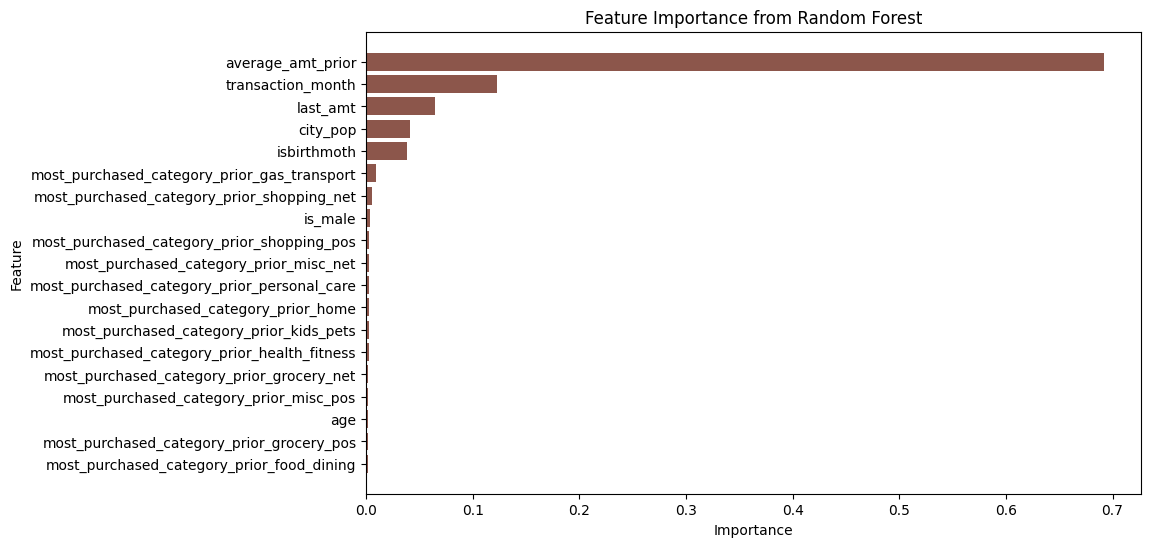

In [101]:
# Get feature importance for best mode l

feature_importances = best_rf.feature_importances_

# Create a DataFrame for better visualization
features = X_train.columns
importance_df = pd.DataFrame({'Feature': features, 'Importance': feature_importances})

# Sort the DataFrame by importance
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Plot feature importances
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='#8c564b')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance from Random Forest')
plt.gca().invert_yaxis()
plt.show()


> Results: the results from the feature importance show that the much of the variance can be explained through average amt_prior, followed by transaction_month, last_amt, city_population and is_birth_month. 

<hr>

## L. Final Outcomes

> Key Learnings: the experiment was successful and multiple insightful models were created with good results on the test set. The best performing model was the Random Forrest Regression model.

> Recommendations: Due to computing limitations, only a small subset of hyperparameters were tested. It is possible that with more time/processing power that a more powerful model could be created. 

<hr>

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=0148d5b6-8246-4b96-8e2c-6c7e24f70959' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>